**Spam Email Classifier**

In [1]:
!pip install wordcloud

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from wordcloud import WordCloud
import re

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", names=["label", "message"])
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text

df["clean_message"] = df["message"].apply(clean_text)
df.head()


,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


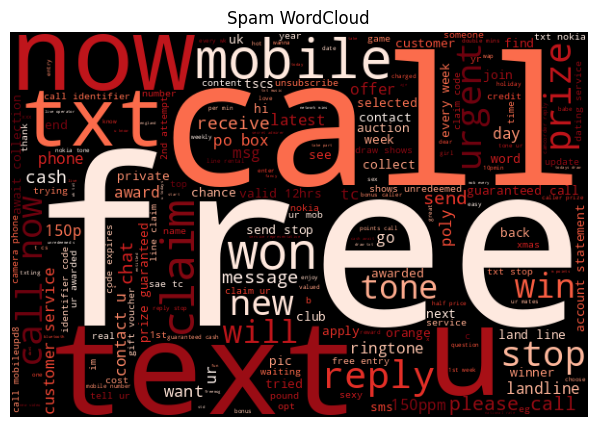

In [4]:
spam_words = " ".join(df[df["label"]=="spam"]["clean_message"])
spam_wc = WordCloud(width=600, height=400, background_color="black", colormap="Reds").generate(spam_words)

plt.figure(figsize=(8,5))
plt.imshow(spam_wc)
plt.axis("off")
plt.title("Spam WordCloud")
plt.show()


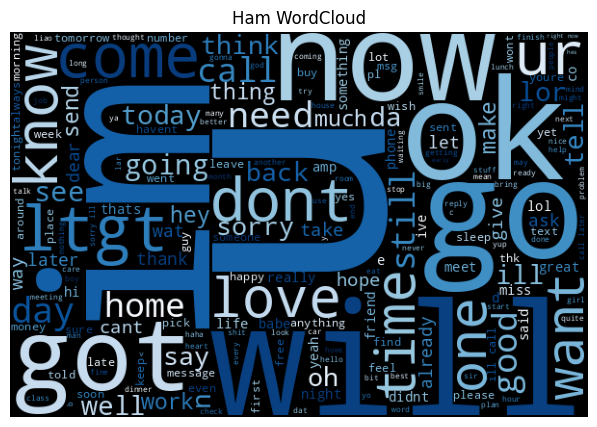

In [5]:
ham_words = " ".join(df[df["label"]=="ham"]["clean_message"])
ham_wc = WordCloud(width=600, height=400, background_color="black", colormap="Blues").generate(ham_words)

plt.figure(figsize=(8,5))
plt.imshow(ham_wc)
plt.axis("off")
plt.title("Ham WordCloud")
plt.show()


In [6]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["clean_message"])
y = df["label"].map({"ham":0, "spam":1})


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9633883704235463

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98      1206
           1       1.00      0.73      0.84       187

    accuracy                           0.96      1393
   macro avg       0.98      0.86      0.91      1393
weighted avg       0.96      0.96      0.96      1393



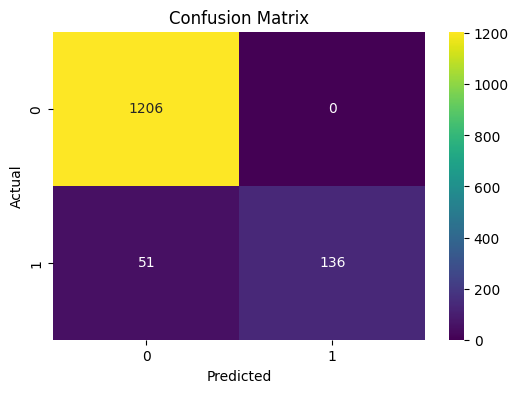

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


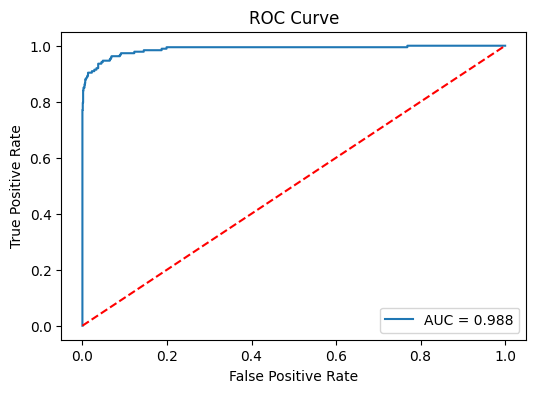

In [11]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)
plt.plot([0,1], [0,1], "r--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


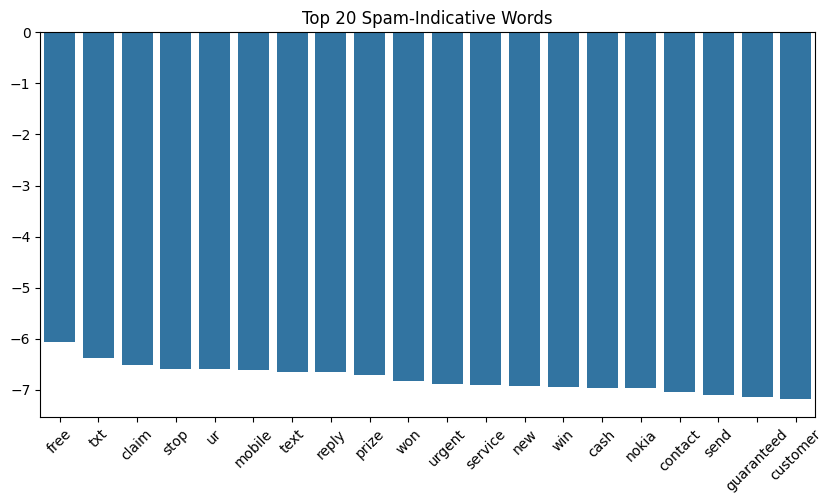

In [13]:
feature_names = np.array(vectorizer.get_feature_names_out())
spam_class_index = model.feature_log_prob_[1].argsort()[::-1]

top_words = feature_names[spam_class_index][:20]

plt.figure(figsize=(10,5))
sns.barplot(x=top_words, y=model.feature_log_prob_[1][spam_class_index][:20])
plt.xticks(rotation=45)
plt.title("Top 20 Spam-Indicative Words")
plt.show()